
**Data_Loading**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/IBM_customer_data.csv")


**EDA**

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.shape

(10000, 14)

In [5]:
df.drop(['RowNumber','CustomerId','Surname'], axis=1, inplace=True)

In [6]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [8]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')

In [11]:
print(df['Geography'].value_counts())
print(df['Gender'].value_counts())

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64
Gender
Male      5457
Female    4543
Name: count, dtype: int64


In [12]:
numeric_cols = ['CreditScore','Age','Balance','EstimatedSalary']
categorical_cols = ['Geography','Gender','Tenure','NumOfProducts','HasCrCard','IsActiveMember']

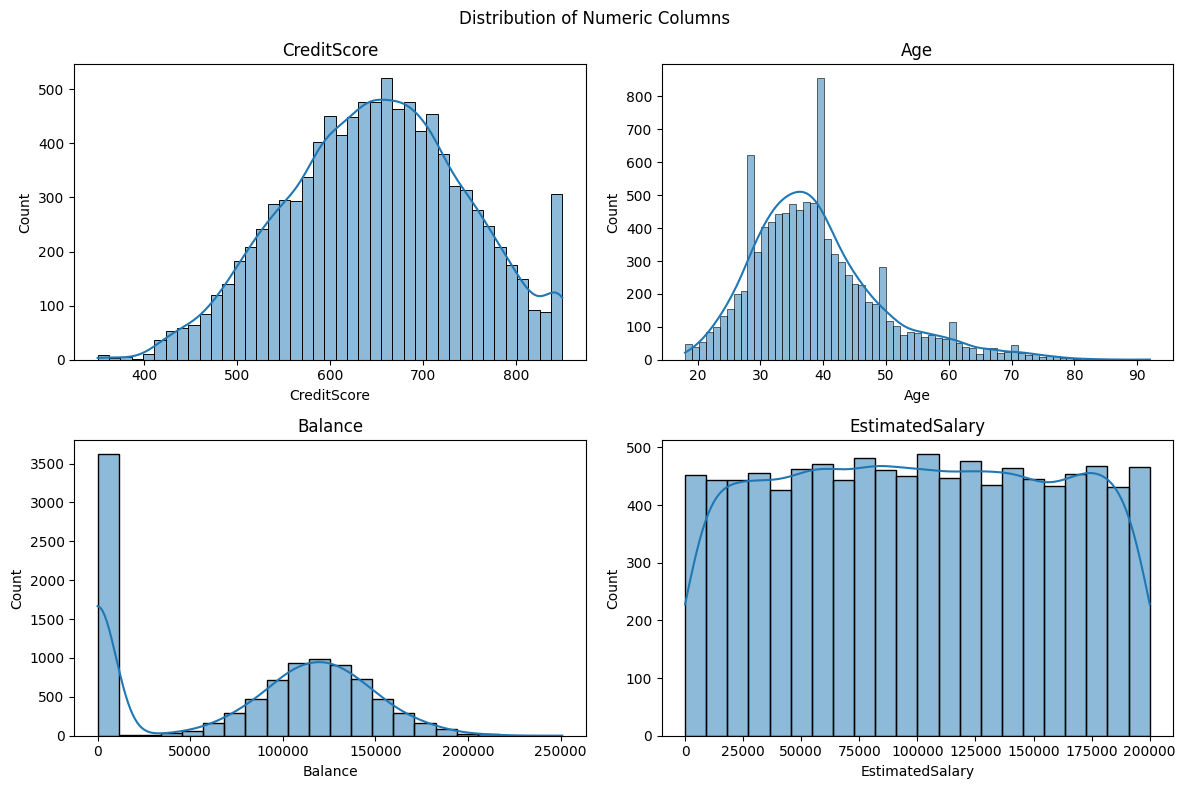

In [13]:
fig,axes = plt.subplots(2,2, figsize=(12,8))
axes = axes.flatten()
for i,col in enumerate(numeric_cols):
    sns.histplot(df[col],kde=True, ax=axes[i])
    axes[i].set_title(col)
plt.suptitle('Distribution of Numeric Columns')
plt.tight_layout()
plt.show()

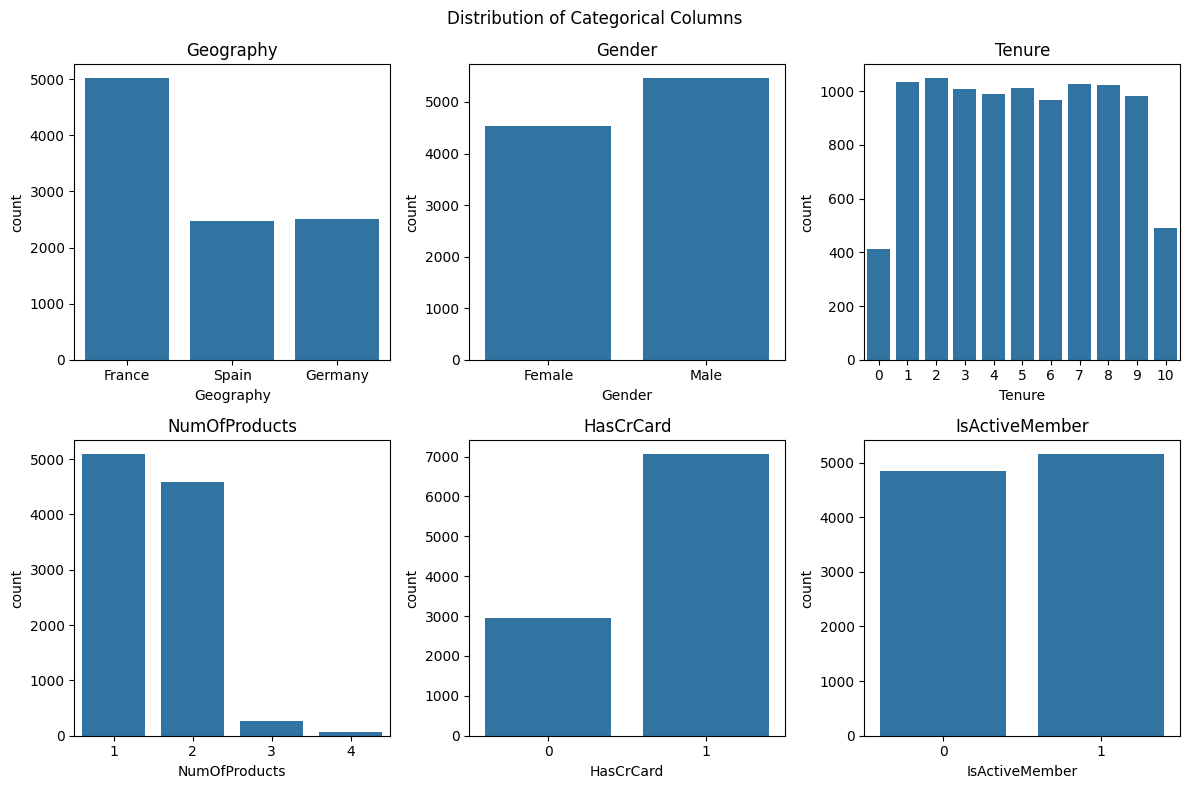

In [14]:
fig,axes = plt.subplots(2,3, figsize=(12,8))
axes = axes.flatten()
for i,col in enumerate(categorical_cols):
    sns.countplot(data=df,x = col, ax=axes[i])
    axes[i].set_title(col)
plt.suptitle('Distribution of Categorical Columns')
plt.tight_layout()
plt.show()

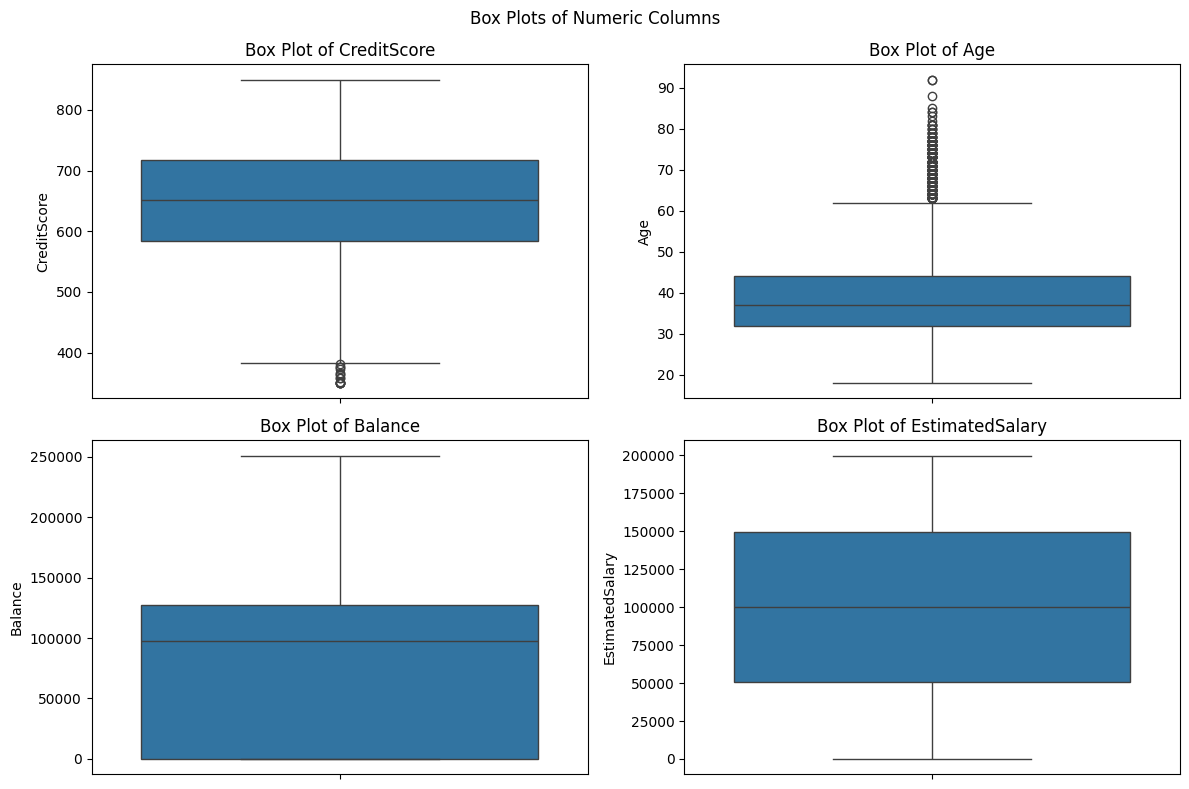

In [15]:
fig,axes = plt.subplots(2,2, figsize=(12,8))
axes = axes.flatten()
for i,col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Box Plot of {col}')
plt.suptitle('Box Plots of Numeric Columns')
plt.tight_layout()
plt.show()

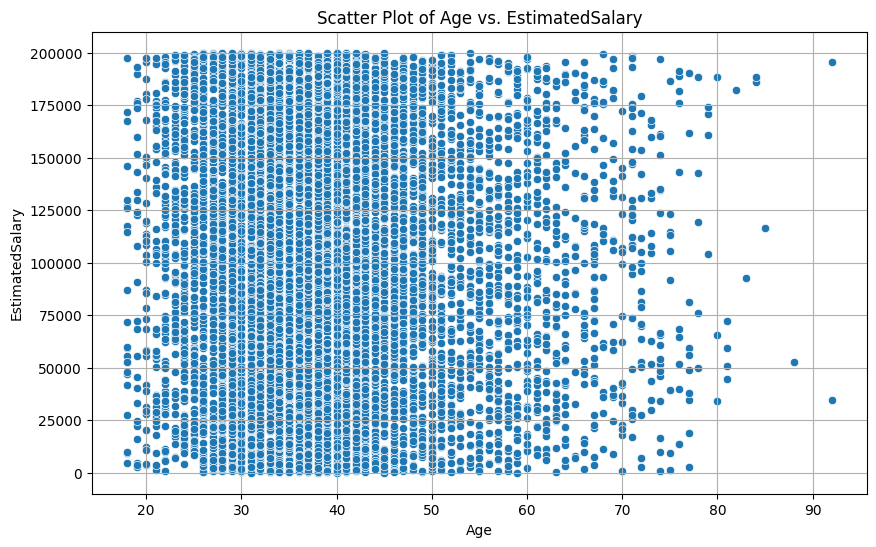

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='EstimatedSalary')
plt.title('Scatter Plot of Age vs. EstimatedSalary')
plt.xlabel('Age')
plt.ylabel('EstimatedSalary')
plt.grid(True)
plt.show()

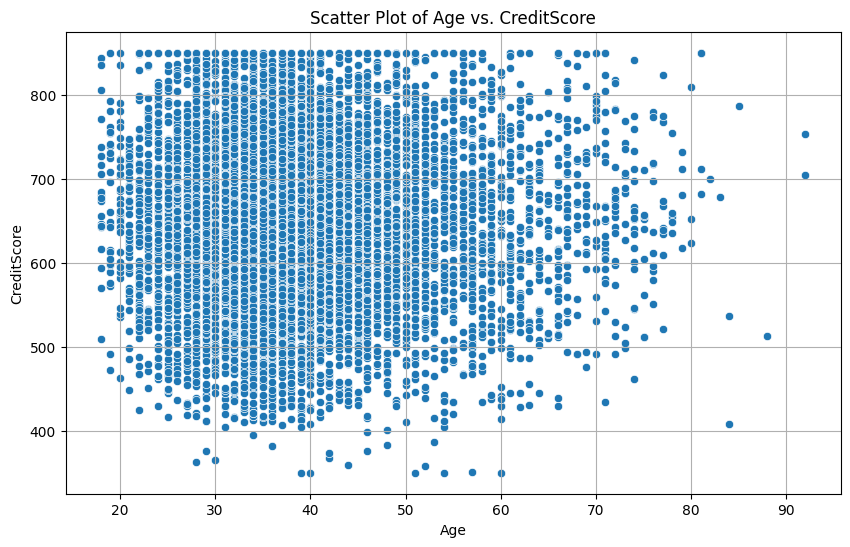

In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='CreditScore')
plt.title('Scatter Plot of Age vs. CreditScore')
plt.xlabel('Age')
plt.ylabel('CreditScore')
plt.grid(True)
plt.show()

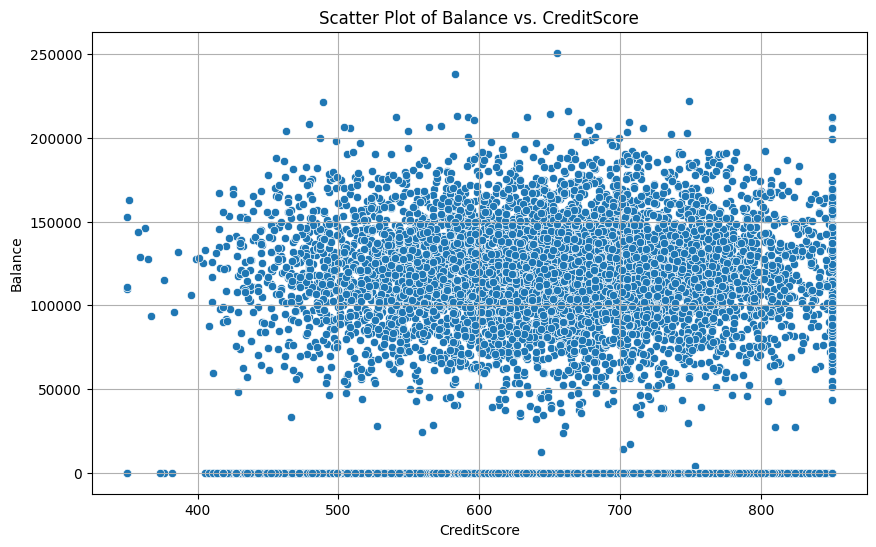

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x ='CreditScore', y='Balance')
plt.title('Scatter Plot of Balance vs. CreditScore')
plt.xlabel('CreditScore')
plt.ylabel('Balance')
plt.grid(True)
plt.show()

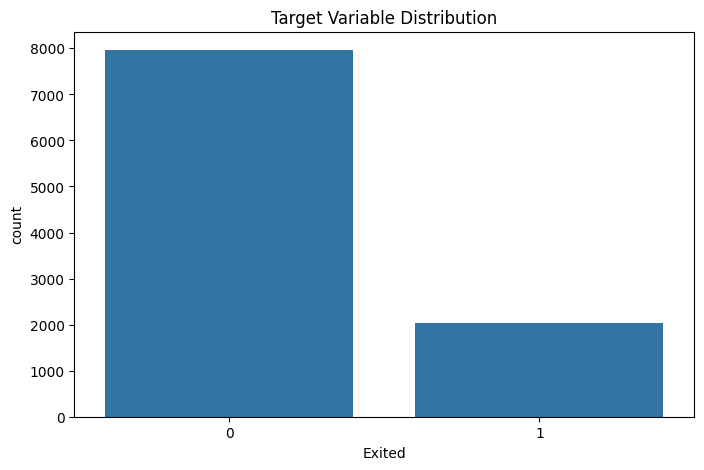

In [19]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x ='Exited')
plt.title('Target Variable Distribution')
plt.show()

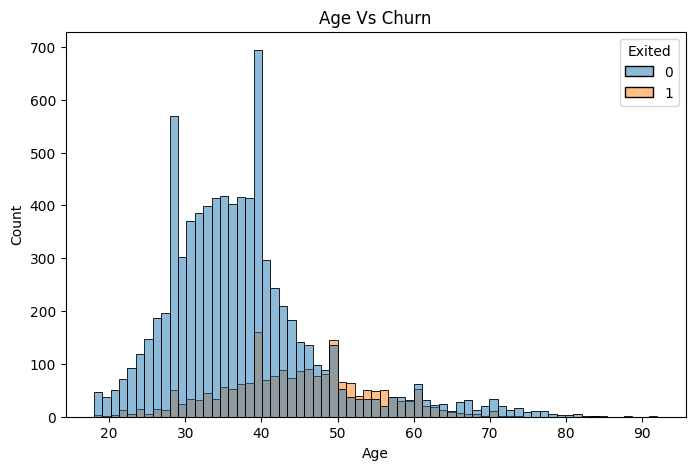

In [20]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Age', hue='Exited')
plt.title('Age Vs Churn')
plt.show()

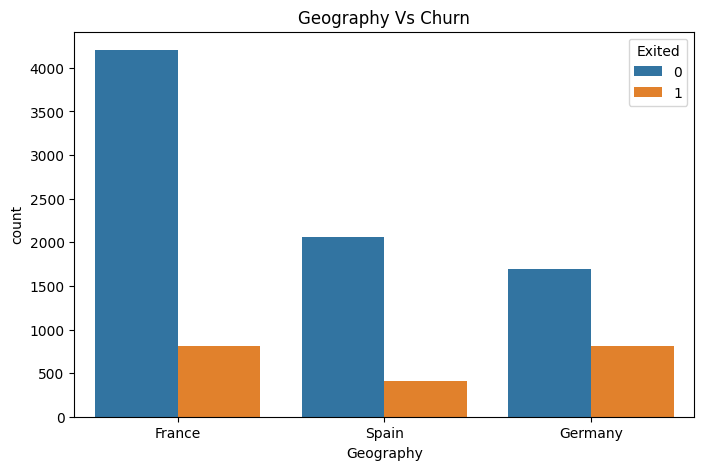

In [21]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Geography', hue='Exited')
plt.title('Geography Vs Churn')
plt.show()

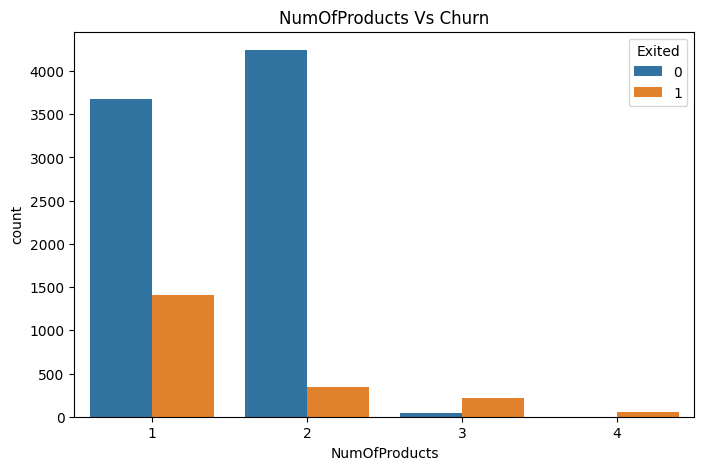

In [22]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='NumOfProducts', hue='Exited')
plt.title('NumOfProducts Vs Churn')
plt.show()

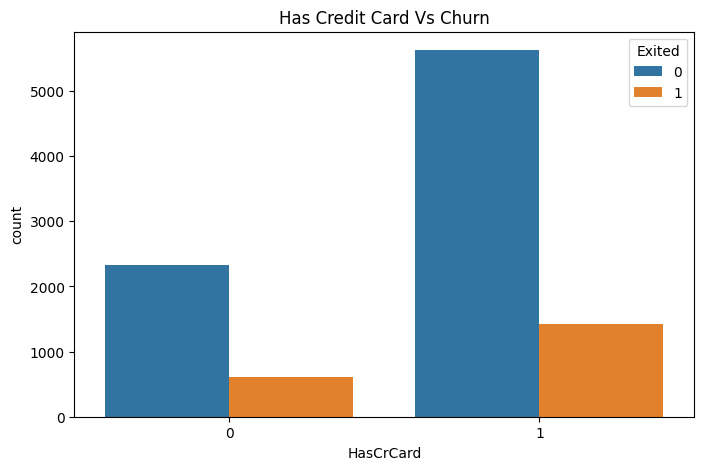

In [23]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='HasCrCard', hue='Exited')
plt.title('Has Credit Card Vs Churn')
plt.show()

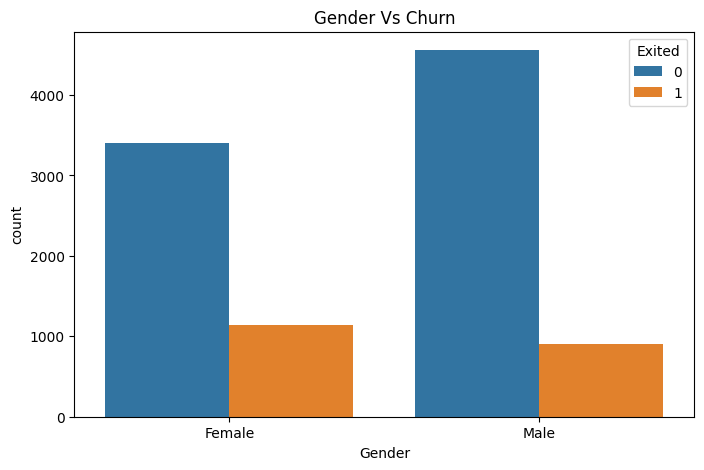

In [24]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Gender', hue='Exited')
plt.title('Gender Vs Churn')
plt.show()

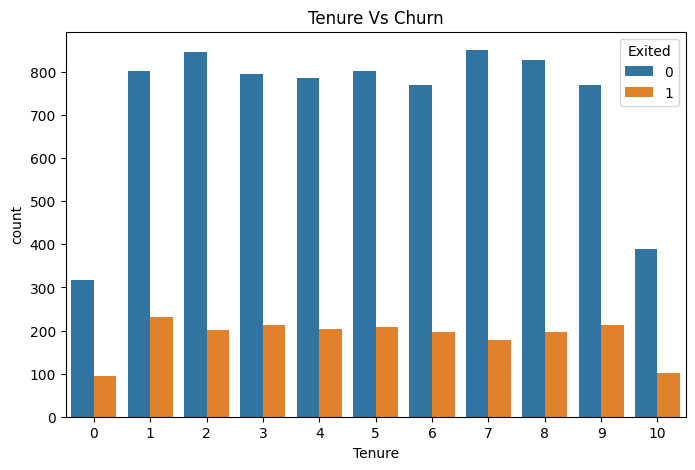

In [25]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Tenure', hue='Exited')
plt.title('Tenure Vs Churn')
plt.show()

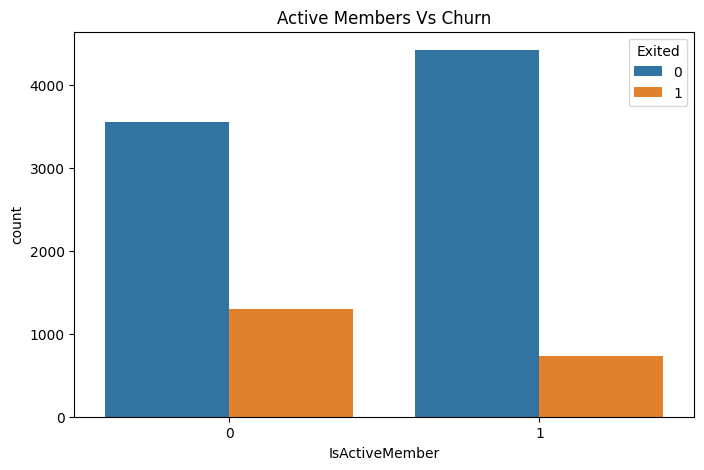

In [26]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='IsActiveMember', hue='Exited')
plt.title('Active Members Vs Churn')
plt.show()

In [27]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df_corr = pd.get_dummies(df, columns=['Geography'], drop_first=True, dtype=int)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,0,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0
2,502,France,0,42,8,159660.80,3,1,0,113931.57,1
3,699,France,0,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0


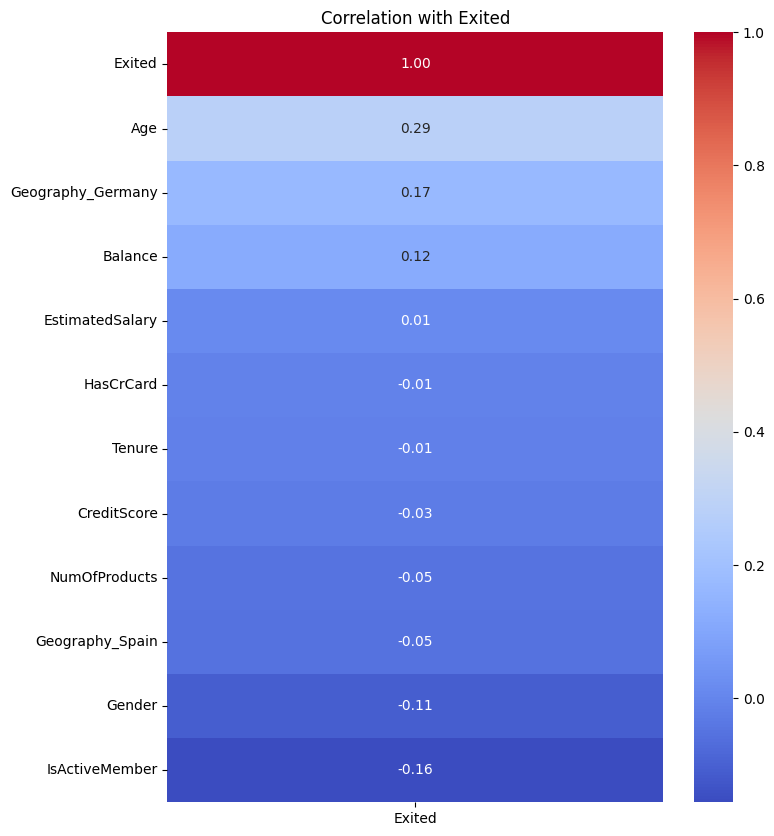

In [28]:
plt.figure(figsize=(8, 10))
sns.heatmap(df_corr.corr()[['Exited']].sort_values(by='Exited', ascending=False), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation with Exited')
plt.show()

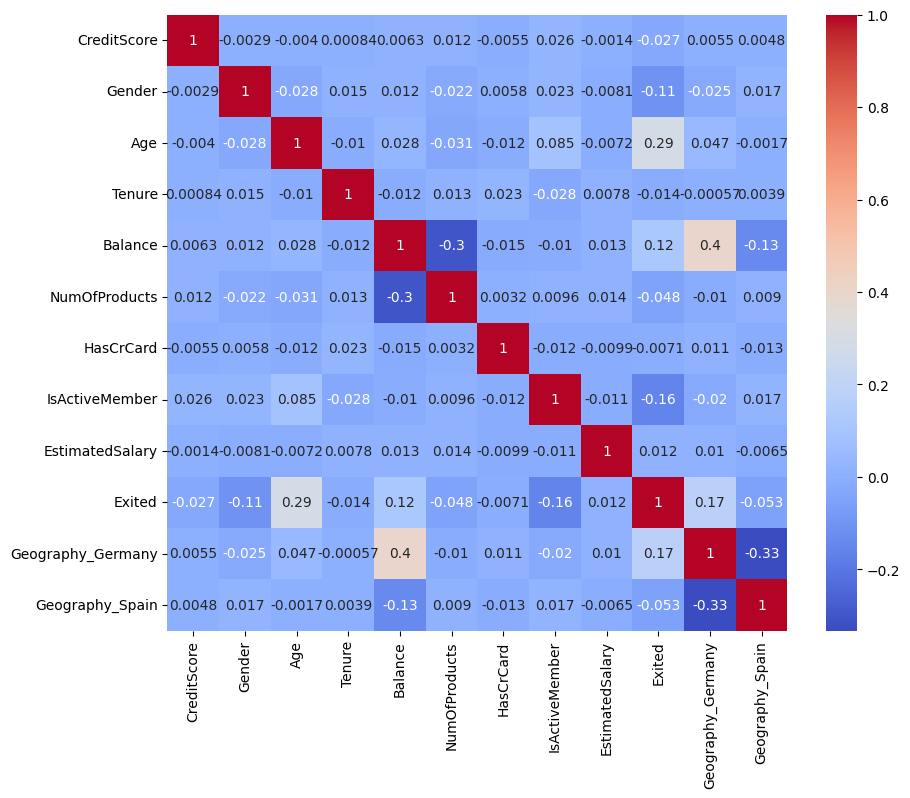

In [29]:
plt.figure(figsize=(10,8))
sns.heatmap(df_corr.corr(), annot=True, cmap="coolwarm")
plt.show()